## **Calculating Magnitude Estimations**

In [68]:
# Magnitude estimation

## **Import Libraries and Setup**

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Set Display Parameters for Data Viewing**

In [40]:
pd.set_option('display.max_columns', None)

## **Upload and Load Data**

In [41]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # This will open a file selector
df = pd.read_csv(next(iter(uploaded.keys())))  # Reads the uploaded CSV


Saving Earthquakes_Dataset (1).csv to Earthquakes_Dataset (1) (1).csv


## **EDA (Exploratory Data Analysis)**

### **Display the DataFrame Contents**

In [42]:
df

,place,mag,magType,type,time,longitude,latitude,depth_km,sig,net,nst,dmin,rms,gap
0,"113 km W of Petrolia, CA",2.56,md,earthquake,2025-02-11 14:34:38.190,-125.614334,40.216499,4.950,101,nc,14.0,0.97600,0.1200,325.00
1,"9 km N of Taft, CA",1.54,ml,earthquake,2025-02-11 14:28:19.490,-119.456833,35.225167,18.240,36,ci,31.0,0.08479,0.2000,116.00
2,"58 km WNW of Petrolia, CA",2.84,md,earthquake,2025-02-11 14:24:27.270,-124.964500,40.401165,4.200,124,nc,30.0,0.48850,0.3700,274.00
3,"24 km NNW of Searles Valley, CA",1.49,ml,earthquake,2025-02-11 14:24:22.730,-117.515663,35.967335,4.010,34,ci,19.0,0.11100,0.1600,83.00
4,"12 km WNW of Anza, CA",0.56,ml,earthquake,2025-02-11 14:12:30.720,-116.803167,33.584500,8.690,5,ci,25.0,0.05820,0.1600,69.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22733,"23 km NNE of Yerington, Nevada",1.20,ml,earthquake,2025-01-16 00:21:33.379000,-119.019300,39.165100,4.600,22,nn,9.0,0.01600,0.0838,111.36
22734,"5 km WSW of San Francisco Zoo, CA",1.23,md,earthquake,2025-01-16 00:17:02.140000,-122.557000,37.708000,10.890,23,nc,18.0,0.06460,0.0500,183.00
22735,"19 km NNE of Yerington, Nevada",1.40,ml,earthquake,2025-01-16 00:12:20.251000,-119.069600,39.144200,4.900,30,nn,11.0,0.03400,0.1107,79.61
22736,"41 km SSE of Tateyama, Japan",4.50,mb,earthquake,2025-01-16 00:07:26.860000,139.958000,34.619700,56.494,312,us,82.0,1.50500,0.5100,111.00


### **Check Shape (Rows and Columns) of DataFrame**

In [43]:
df.shape

(22738, 14)

### **View Data Summary ( Information and Data Types)**

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22738 entries, 0 to 22737
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   place      22738 non-null  object 
 1   mag        22738 non-null  float64
 2   magType    22738 non-null  object 
 3   type       22738 non-null  object 
 4   time       22738 non-null  object 
 5   longitude  22738 non-null  float64
 6   latitude   22738 non-null  float64
 7   depth_km   22738 non-null  float64
 8   sig        22738 non-null  int64  
 9   net        22738 non-null  object 
 10  nst        22738 non-null  float64
 11  dmin       22738 non-null  float64
 12  rms        22738 non-null  float64
 13  gap        22738 non-null  float64
dtypes: float64(8), int64(1), object(5)
memory usage: 2.4+ MB


### **Generate Descriptive Statistics**

In [45]:
df.describe()

,mag,longitude,latitude,depth_km,sig,nst,dmin,rms,gap
count,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000
mean,1.481742,-100.489911,36.216841,15.467917,67.213827,24.452458,0.487572,0.216859,111.526936
std,1.468251,69.446986,17.141390,53.243223,109.585431,22.927217,1.823934,0.264214,63.769321
min,-1.890000,-179.964000,-73.220400,-3.460000,0.000000,3.000000,0.000000,0.000000,14.000000
25%,0.600000,-122.821831,33.506333,2.270000,6.000000,9.000000,0.013820,0.060000,65.000000
50%,1.110000,-119.039833,38.492850,6.245400,19.000000,17.000000,0.052585,0.130000,91.000000
75%,1.910000,-110.815375,40.354167,10.000000,56.750000,31.000000,0.125000,0.210000,146.000000
max,7.600000,179.971600,82.479300,690.121000,1177.000000,242.000000,29.638000,1.720000,348.000000


### **View First Few Rows**

In [46]:
df.head()

,place,mag,magType,type,time,longitude,latitude,depth_km,sig,net,nst,dmin,rms,gap
0,"113 km W of Petrolia, CA",2.56,md,earthquake,2025-02-11 14:34:38.190,-125.614334,40.216499,4.95,101,nc,14.0,0.97600,0.12,325.0
1,"9 km N of Taft, CA",1.54,ml,earthquake,2025-02-11 14:28:19.490,-119.456833,35.225167,18.24,36,ci,31.0,0.08479,0.20,116.0
2,"58 km WNW of Petrolia, CA",2.84,md,earthquake,2025-02-11 14:24:27.270,-124.964500,40.401165,4.20,124,nc,30.0,0.48850,0.37,274.0
3,"24 km NNW of Searles Valley, CA",1.49,ml,earthquake,2025-02-11 14:24:22.730,-117.515663,35.967335,4.01,34,ci,19.0,0.11100,0.16,83.0
4,"12 km WNW of Anza, CA",0.56,ml,earthquake,2025-02-11 14:12:30.720,-116.803167,33.584500,8.69,5,ci,25.0,0.05820,0.16,69.0


## **Data Preprocessing**

### **Drop Column**

In [47]:
df = df.drop(columns='place')

### **Display Updated DataFrame**

In [48]:
df

,mag,magType,type,time,longitude,latitude,depth_km,sig,net,nst,dmin,rms,gap
0,2.56,md,earthquake,2025-02-11 14:34:38.190,-125.614334,40.216499,4.950,101,nc,14.0,0.97600,0.1200,325.00
1,1.54,ml,earthquake,2025-02-11 14:28:19.490,-119.456833,35.225167,18.240,36,ci,31.0,0.08479,0.2000,116.00
2,2.84,md,earthquake,2025-02-11 14:24:27.270,-124.964500,40.401165,4.200,124,nc,30.0,0.48850,0.3700,274.00
3,1.49,ml,earthquake,2025-02-11 14:24:22.730,-117.515663,35.967335,4.010,34,ci,19.0,0.11100,0.1600,83.00
4,0.56,ml,earthquake,2025-02-11 14:12:30.720,-116.803167,33.584500,8.690,5,ci,25.0,0.05820,0.1600,69.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22733,1.20,ml,earthquake,2025-01-16 00:21:33.379000,-119.019300,39.165100,4.600,22,nn,9.0,0.01600,0.0838,111.36
22734,1.23,md,earthquake,2025-01-16 00:17:02.140000,-122.557000,37.708000,10.890,23,nc,18.0,0.06460,0.0500,183.00
22735,1.40,ml,earthquake,2025-01-16 00:12:20.251000,-119.069600,39.144200,4.900,30,nn,11.0,0.03400,0.1107,79.61
22736,4.50,mb,earthquake,2025-01-16 00:07:26.860000,139.958000,34.619700,56.494,312,us,82.0,1.50500,0.5100,111.00


## **Feature Engineering**

### **One-Hot Encode 'type' Column**

In [49]:
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype = int)

### **One-Hot Encode 'magType' Column**

In [50]:
df = pd.get_dummies(df, columns=['magType'], drop_first=True, dtype = int)

### **One-Hot Encode 'net' Column**

In [51]:
df = pd.get_dummies(df, columns=['net'], drop_first=True, dtype = int)

In [52]:
df

,mag,time,longitude,latitude,depth_km,sig,nst,dmin,rms,gap,type_explosion,type_quarry blast,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_mw,magType_mwb,magType_mwr,magType_mww,net_ci,net_hv,net_mb,net_nc,net_nm,net_nn,net_ok,net_pr,net_se,net_tx,net_us,net_uu,net_uw
0,2.56,2025-02-11 14:34:38.190,-125.614334,40.216499,4.950,101,14.0,0.97600,0.1200,325.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1.54,2025-02-11 14:28:19.490,-119.456833,35.225167,18.240,36,31.0,0.08479,0.2000,116.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2.84,2025-02-11 14:24:27.270,-124.964500,40.401165,4.200,124,30.0,0.48850,0.3700,274.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,1.49,2025-02-11 14:24:22.730,-117.515663,35.967335,4.010,34,19.0,0.11100,0.1600,83.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0.56,2025-02-11 14:12:30.720,-116.803167,33.584500,8.690,5,25.0,0.05820,0.1600,69.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22733,1.20,2025-01-16 00:21:33.379000,-119.019300,39.165100,4.600,22,9.0,0.01600,0.0838,111.36,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
22734,1.23,2025-01-16 00:17:02.140000,-122.557000,37.708000,10.890,23,18.0,0.06460,0.0500,183.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
22735,1.40,2025-01-16 00:12:20.251000,-119.069600,39.144200,4.900,30,11.0,0.03400,0.1107,79.61,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
22736,4.50,2025-01-16 00:07:26.860000,139.958000,34.619700,56.494,312,82.0,1.50500,0.5100,111.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


### **Convert time Column to Datetime**

In [53]:
df['time'] = pd.to_datetime(df['time'], format='mixed', errors='coerce')


### **Extract Date and Time Features from time Column**

In [54]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['hour'] = df['time'].dt.hour
df['minute'] = df['time'].dt.minute
df['dayofweek'] = df['time'].dt.dayofweek   # 0=Monday, 6=Sunday
df['dayofyear'] = df['time'].dt.dayofyear

### **Drop Original time Column**

In [55]:
df = df.drop(columns='time')

In [56]:
df

,mag,longitude,latitude,depth_km,sig,nst,dmin,rms,gap,type_explosion,type_quarry blast,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_mw,magType_mwb,magType_mwr,magType_mww,net_ci,net_hv,net_mb,net_nc,net_nm,net_nn,net_ok,net_pr,net_se,net_tx,net_us,net_uu,net_uw,year,month,day,hour,minute,dayofweek,dayofyear
0,2.56,-125.614334,40.216499,4.950,101,14.0,0.97600,0.1200,325.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2025,2,11,14,34,1,42
1,1.54,-119.456833,35.225167,18.240,36,31.0,0.08479,0.2000,116.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2025,2,11,14,28,1,42
2,2.84,-124.964500,40.401165,4.200,124,30.0,0.48850,0.3700,274.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2025,2,11,14,24,1,42
3,1.49,-117.515663,35.967335,4.010,34,19.0,0.11100,0.1600,83.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2025,2,11,14,24,1,42
4,0.56,-116.803167,33.584500,8.690,5,25.0,0.05820,0.1600,69.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2025,2,11,14,12,1,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22733,1.20,-119.019300,39.165100,4.600,22,9.0,0.01600,0.0838,111.36,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2025,1,16,0,21,3,16
22734,1.23,-122.557000,37.708000,10.890,23,18.0,0.06460,0.0500,183.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2025,1,16,0,17,3,16
22735,1.40,-119.069600,39.144200,4.900,30,11.0,0.03400,0.1107,79.61,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2025,1,16,0,12,3,16
22736,4.50,139.958000,34.619700,56.494,312,82.0,1.50500,0.5100,111.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2025,1,16,0,7,3,16


### **Drop Column: 'sig'**

In [57]:
df = df.drop(columns='sig')

In [58]:
df

,mag,longitude,latitude,depth_km,nst,dmin,rms,gap,type_explosion,type_quarry blast,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_mw,magType_mwb,magType_mwr,magType_mww,net_ci,net_hv,net_mb,net_nc,net_nm,net_nn,net_ok,net_pr,net_se,net_tx,net_us,net_uu,net_uw,year,month,day,hour,minute,dayofweek,dayofyear
0,2.56,-125.614334,40.216499,4.950,14.0,0.97600,0.1200,325.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2025,2,11,14,34,1,42
1,1.54,-119.456833,35.225167,18.240,31.0,0.08479,0.2000,116.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2025,2,11,14,28,1,42
2,2.84,-124.964500,40.401165,4.200,30.0,0.48850,0.3700,274.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2025,2,11,14,24,1,42
3,1.49,-117.515663,35.967335,4.010,19.0,0.11100,0.1600,83.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2025,2,11,14,24,1,42
4,0.56,-116.803167,33.584500,8.690,25.0,0.05820,0.1600,69.00,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2025,2,11,14,12,1,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22733,1.20,-119.019300,39.165100,4.600,9.0,0.01600,0.0838,111.36,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2025,1,16,0,21,3,16
22734,1.23,-122.557000,37.708000,10.890,18.0,0.06460,0.0500,183.00,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2025,1,16,0,17,3,16
22735,1.40,-119.069600,39.144200,4.900,11.0,0.03400,0.1107,79.61,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2025,1,16,0,12,3,16
22736,4.50,139.958000,34.619700,56.494,82.0,1.50500,0.5100,111.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2025,1,16,0,7,3,16


### **Define Features (X) and Target (y)**

In [59]:
X = df.drop(columns = 'mag', axis = 1)
y = df['mag']

## **Implement XGBoost Model**

In [60]:
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor
import numpy as np

# Define model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Define 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate model using negative RMSE (because sklearn returns negative for minimization metrics)
scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')

# Convert to positive RMSE
rmse_scores = -scores



In [61]:
print("RMSE for each fold:", rmse_scores)
print("Average RMSE:", np.mean(rmse_scores))
print("Standard deviation:", np.std(rmse_scores))




RMSE for each fold: [0.26272415 0.26297045 0.26690107 0.27660423 0.25915423]
Average RMSE: 0.2656708255248824
Standard deviation: 0.005991558324738553


In [62]:
# Mean Absolute Error (MAE)
mae_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
mae_scores = -mae_scores  # convert to positive
print("MAE per fold:", mae_scores)
print("Average MAE:", np.mean(mae_scores))



MAE per fold: [0.18850821 0.20076645 0.18502491 0.19130503 0.18261684]
Average MAE: 0.18964428872612168


In [63]:
# R² Score
r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R² per fold:", r2_scores)
print("Average R²:", np.mean(r2_scores))

R² per fold: [0.97033642 0.9625676  0.97275976 0.97143319 0.97129326]
Average R²: 0.969678046532826


## **Implement Random Forest Model**

In [64]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
print("RandomForestRegressor model initialized.")

RandomForestRegressor model initialized.


In [65]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate model using negative RMSE
rmse_scores_rf = cross_val_score(rf_model, X, y, cv=kf, scoring='neg_root_mean_squared_error')

# Convert to positive RMSE
rmse_scores_rf = -rmse_scores_rf

print("RMSE for each fold (Random Forest):", rmse_scores_rf)
print("Average RMSE (Random Forest):", np.mean(rmse_scores_rf))
print("Standard deviation (Random Forest):", np.std(rmse_scores_rf))

RMSE for each fold (Random Forest): [0.44290991 0.43185887 0.43025878 0.44718572 0.42021593]
Average RMSE (Random Forest): 0.43448584050675676
Standard deviation (Random Forest): 0.00959845095156467


In [66]:
mae_scores_rf = cross_val_score(rf_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
mae_scores_rf = -mae_scores_rf

print("MAE per fold (Random Forest):", mae_scores_rf)
print("Average MAE (Random Forest):", np.mean(mae_scores_rf))

MAE per fold (Random Forest): [0.33127916 0.32429784 0.32128637 0.33281828 0.3142638 ]
Average MAE (Random Forest): 0.32478908875460527


In [67]:
r2_scores_rf = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print("R² per fold (Random Forest):", r2_scores_rf)
print("Average R² (Random Forest):", np.mean(r2_scores_rf))

R² per fold (Random Forest): [0.90466721 0.91615214 0.91348592 0.90596296 0.92063934]
Average R² (Random Forest): 0.9121815123388807


## **Comparison of Both Models**

In [84]:
print("--- XGBoost Model Performance ---")
print(f"Average RMSE (XGBoost): {np.mean(rmse_scores):.4f}")
print(f"Average MAE (XGBoost): {np.mean(mae_scores):.4f}")
print(f"Average R\u00b2 (XGBoost): {np.mean(r2_scores):.4f}")

print("\n--- Random Forest Model Performance ---")
print(f"Average RMSE (Random Forest): {np.mean(rmse_scores_rf):.4f}")
print(f"Average MAE (Random Forest): {np.mean(mae_scores_rf):.4f}")
print(f"Average R\u00b2 (Random Forest): {np.mean(r2_scores_rf):.4f}")

--- XGBoost Model Performance ---
Average RMSE (XGBoost): 0.2657
Average MAE (XGBoost): 0.1896
Average R² (XGBoost): 0.9697

--- Random Forest Model Performance ---
Average RMSE (Random Forest): 0.4345
Average MAE (Random Forest): 0.3248
Average R² (Random Forest): 0.9122


## **Visualize Model Comparison**

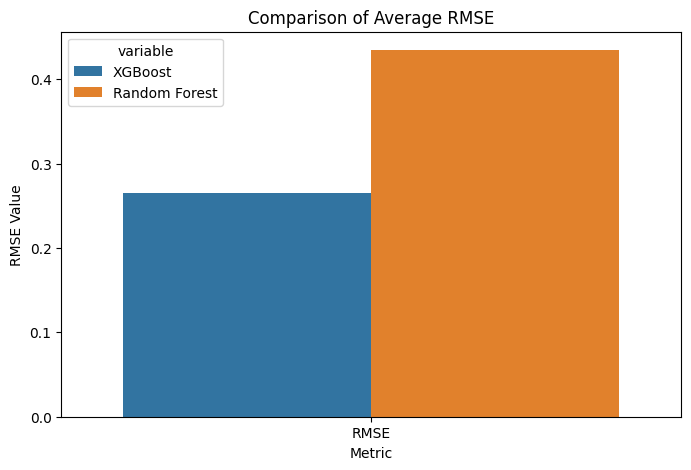

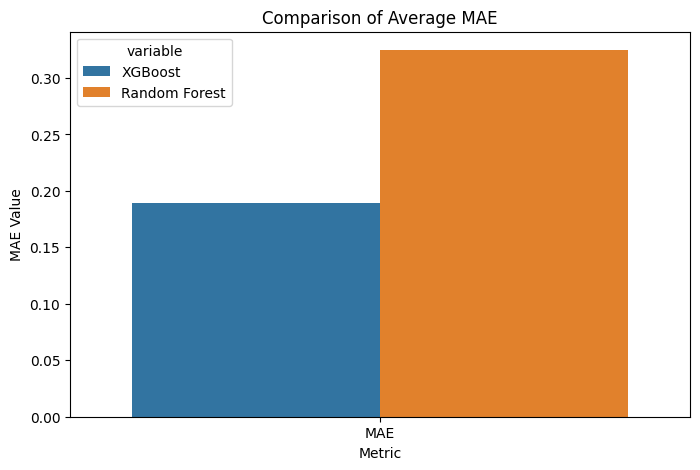

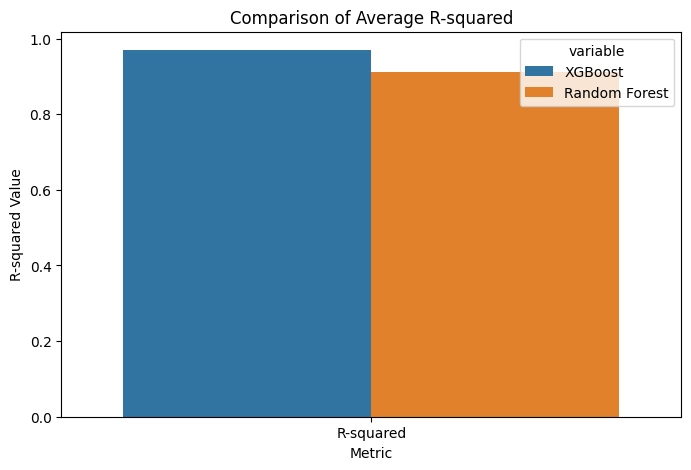

In [85]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='value', hue='variable', data=pd.melt(comparison_df[comparison_df['Metric'] == 'RMSE'], id_vars=['Metric']))
plt.title('Comparison of Average RMSE')
plt.xlabel('Metric')
plt.ylabel('RMSE Value')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='value', hue='variable', data=pd.melt(comparison_df[comparison_df['Metric'] == 'MAE'], id_vars=['Metric']))
plt.title('Comparison of Average MAE')
plt.xlabel('Metric')
plt.ylabel('MAE Value')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='value', hue='variable', data=pd.melt(comparison_df[comparison_df['Metric'] == 'R-squared'], id_vars=['Metric']))
plt.title('Comparison of Average R-squared')
plt.xlabel('Metric')
plt.ylabel('R-squared Value')
plt.show()

## **Retrain Best Model and Analyze Feature Importance**

In [78]:
model.fit(X, y)
print("XGBoost model retrained on the entire dataset.")

XGBoost model retrained on the entire dataset.


Top 15 Feature Importances:
              Feature  Importance
27             net_us    0.956834
12         magType_ml    0.012727
1            latitude    0.005959
16        magType_mww    0.004461
9       magType_mb_lg    0.002447
8   type_quarry blast    0.002075
3                 nst    0.001861
17             net_ci    0.001723
4                dmin    0.001717
22             net_nn    0.001372
7      type_explosion    0.000863
5                 rms    0.000854
0           longitude    0.000782
10         magType_md    0.000764
23             net_ok    0.000738


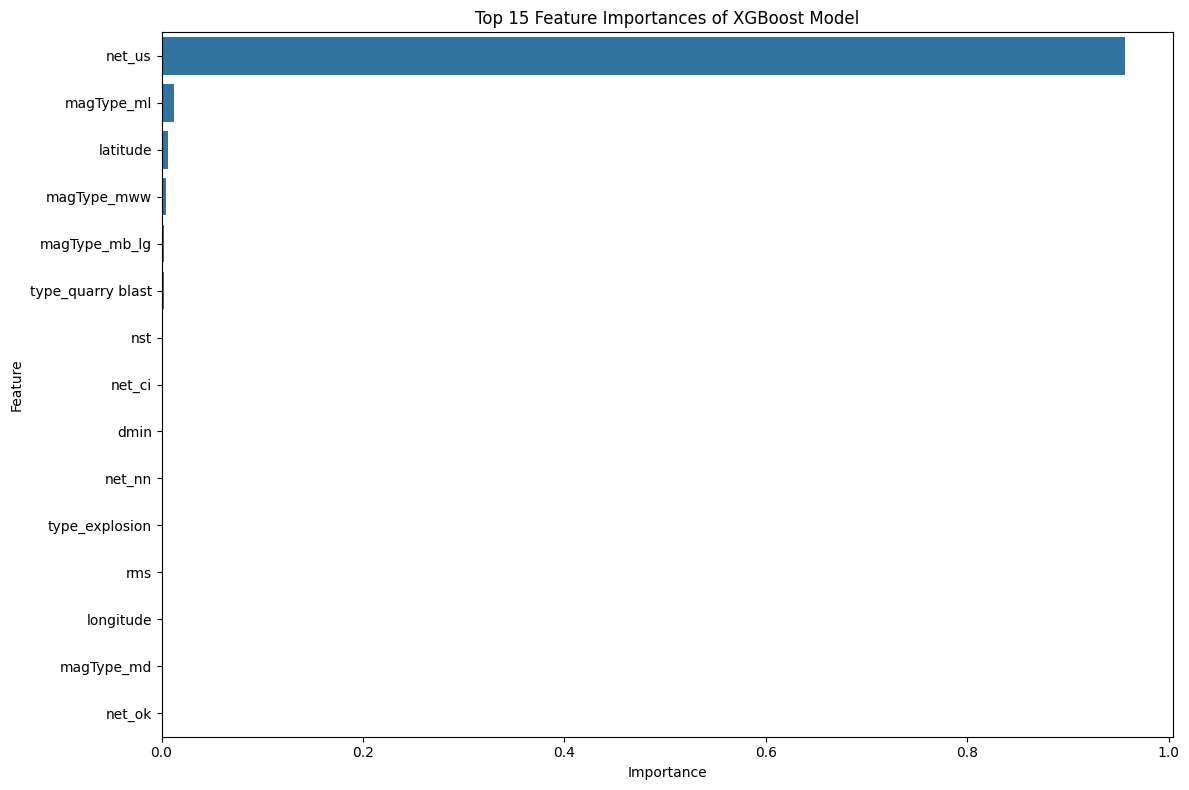

In [79]:
feature_importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 15 Feature Importances:")
print(importance_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances of XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## **Save Best Model**

In [80]:
import joblib

# Save the retrained XGBoost model
joblib.dump(model, 'xgboost_earthquake_magnitude_model.pkl')
print("XGBoost model saved successfully to 'xgboost_earthquake_magnitude_model.pkl'.")

XGBoost model saved successfully to 'xgboost_earthquake_magnitude_model.pkl'.


## **Correlation Matrix**

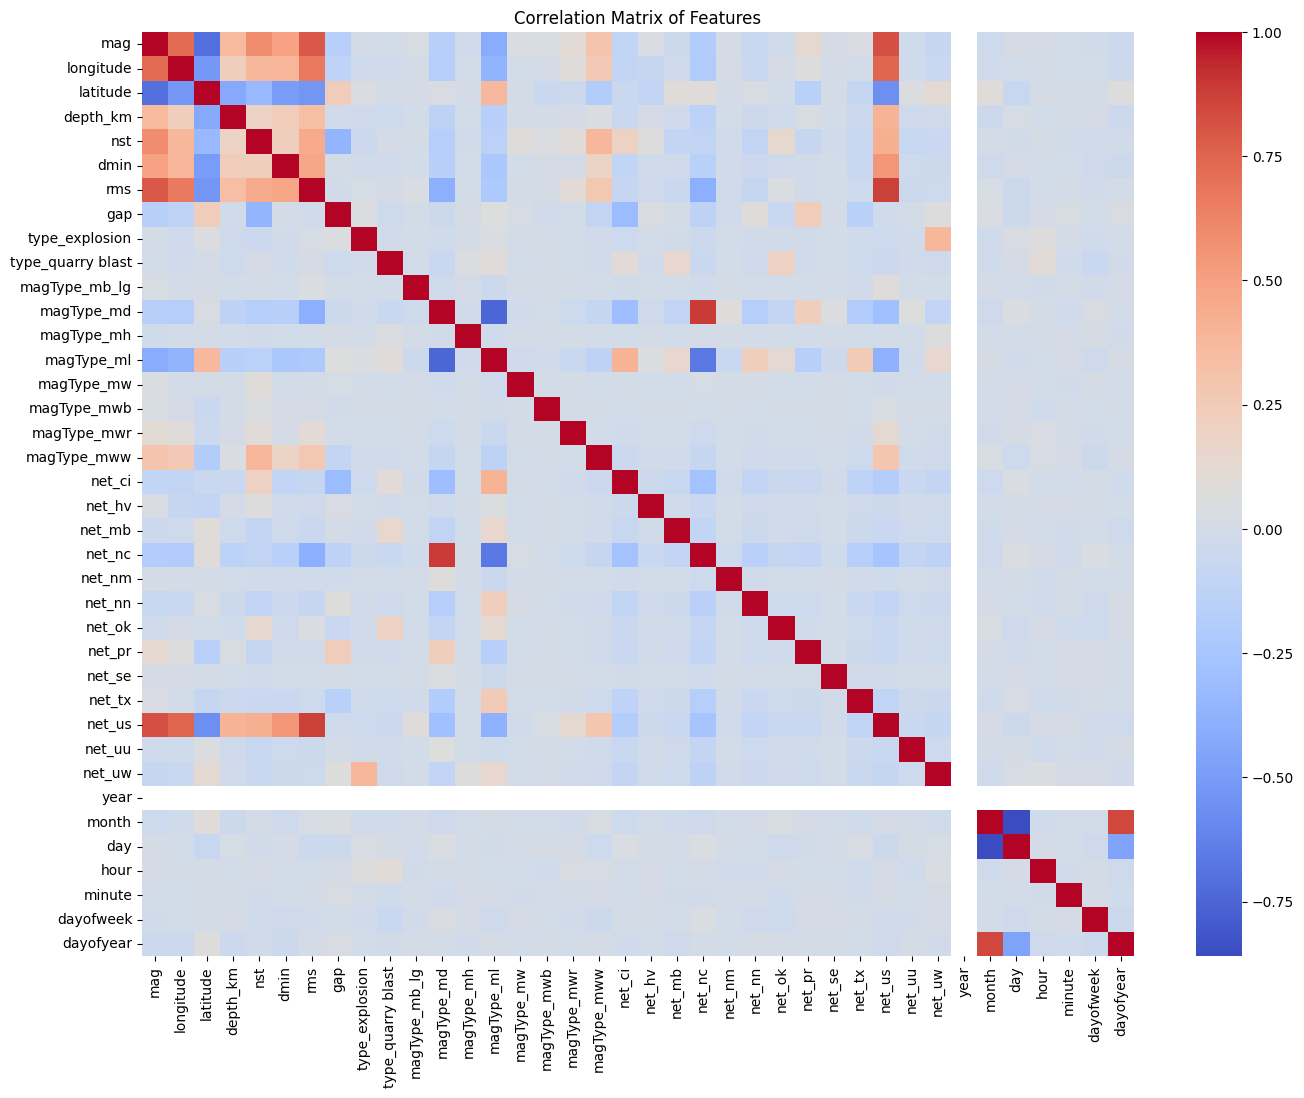

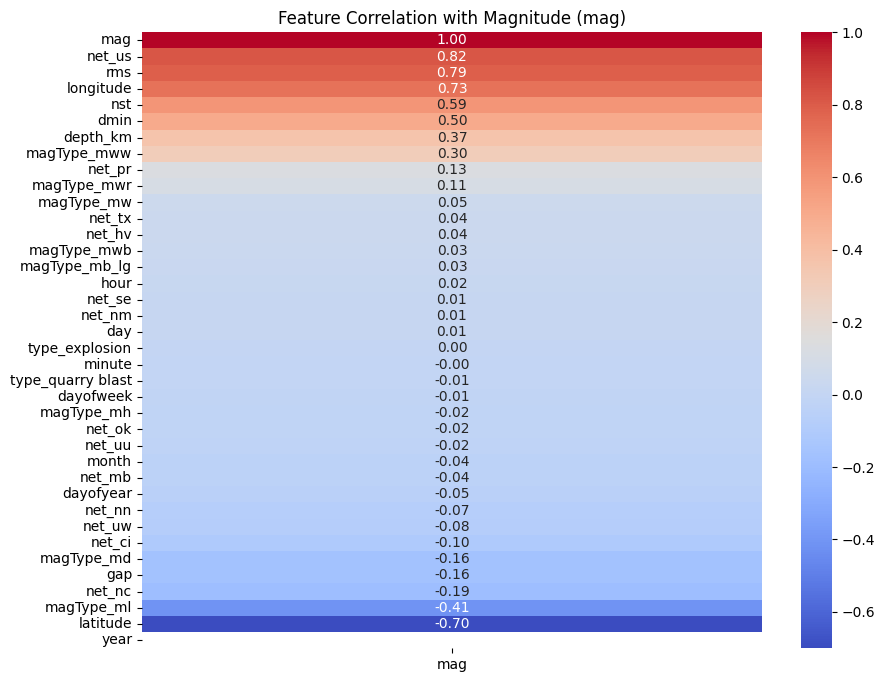

In [81]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr()[['mag']].sort_values(by='mag', ascending=False), cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Feature Correlation with Magnitude (mag)')
plt.show()

## **Analyzing the 'mag' Column Properties**

In [87]:
# Check these properties of your magnitude column:
print(f"Magnitude range: {df['mag'].min()} to {df['mag'].max()}")
print(f"Magnitude std: {df['mag'].std()}")
print(f"Value counts:\n{df['mag'].value_counts().head()}")

Magnitude range: -1.89 to 7.6
Magnitude std: 1.4682506495159824
Value counts:
mag
4.4    440
4.3    354
4.2    352
4.5    311
1.5    309
Name: count, dtype: int64
